# 10 — Multi-rate統合とpolicy

## 目的
100 Hzの未来policyと500 Hzの現在実行を、zero-order holdと誤解せず理解する。

実装対応:
- `LeggedController::setupMrt()`
- `LeggedController::starting()`
- `LeggedController::update()`


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / "pyproject.toml").exists():
        ROOT = candidate
        break

np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({"figure.figsize": (9, 4), "axes.grid": True})
print("repository:", ROOT)


repository: /home/takuya/work/mpc_dog


NMPC threadは `advanceMpc()` でpolicyを更新する。500 Hz側は毎周期:

1. 新しい観測を共有
2. `updatePolicy()`
3. `evaluatePolicy(t, x, optimizedState, optimizedInput, plannedMode)`
4. その1点をWBCへ

`useFeedbackPolicy=false` なので、実装設定ではstate feedback gainより軌道補間が中心。
NMPC更新間にも時刻は進むため、同じ入力値を5回固定する、と単純化しない。


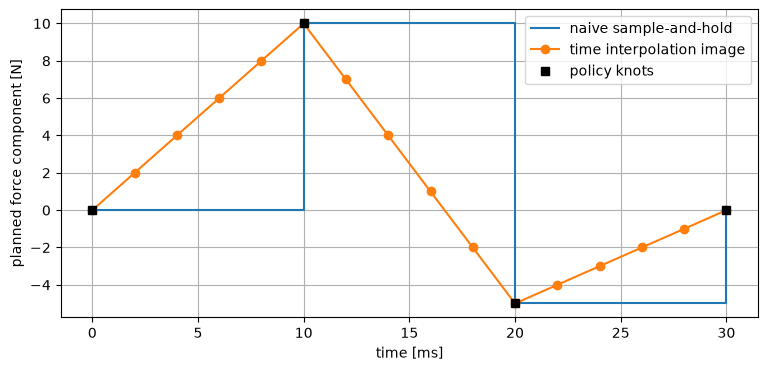

In [2]:
# 10 msごとのpolicy knotを、2 msの実行時刻で線形評価する教育例。
t_policy = np.array([0.000, 0.010, 0.020, 0.030])
u_policy = np.array([0.0, 10.0, -5.0, 0.0])
t_fast = np.arange(0, 0.0301, 0.002)
u_interp = np.interp(t_fast, t_policy, u_policy)
u_hold = u_policy[np.minimum(np.searchsorted(t_policy, t_fast, side="right")-1,
                             len(u_policy)-1)]

plt.step(t_fast*1e3, u_hold, where="post", label="naive sample-and-hold")
plt.plot(t_fast*1e3, u_interp, "o-", label="time interpolation image")
plt.plot(t_policy*1e3, u_policy, "ks", label="policy knots")
plt.xlabel("time [ms]"); plt.ylabel("planned force component [N]")
plt.legend(); plt.show()


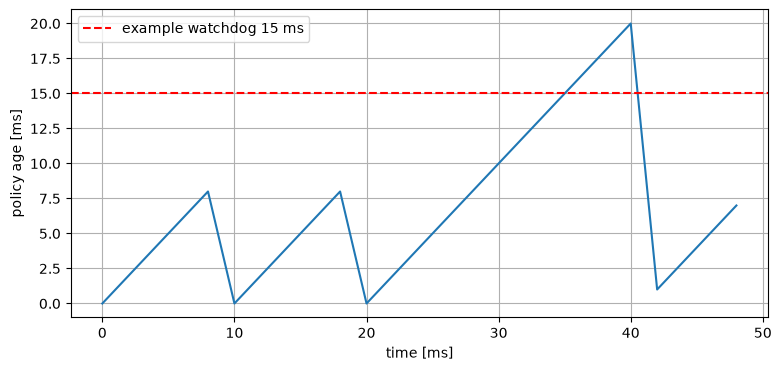

max policy age [ms]: 20.0


In [3]:
# policy ageを監視する最小ロジック。実システムではclockとthread-safe timestampを使う。
fast_times = np.arange(0, 0.050, 0.002)
update_times = np.array([0.000, 0.010, 0.020, 0.041])  # 30 ms更新が遅れた例
ages = []
for t in fast_times:
    available = update_times[update_times <= t]
    ages.append(t - available[-1])
ages = np.asarray(ages)
plt.plot(fast_times*1e3, ages*1e3)
plt.axhline(15, color="r", ls="--", label="example watchdog 15 ms")
plt.xlabel("time [ms]"); plt.ylabel("policy age [ms]"); plt.legend(); plt.show()
print("max policy age [ms]:", ages.max()*1e3)


## 統合時に測るもの
solver wall timeの平均だけでは不十分。

- worst-case / percentile solve time
- policy age
- missed deadline連続回数
- 接触mode切替とpolicy時刻のずれ
- WBC solve time・status
- sensor timestampと制御時刻

`starting()` は初期policyを受け取るまでMPCを進める。初期化を飛ばすと、
未定義policyをWBCへ渡す危険がある。


## 章固有の背景
                solver deadlineを満たしても、古いpolicyを実行すれば閉ループ性能は崩れる。

                ## 章固有の目的
                observation共有、policy swap、時刻評価、WBC実行を100/500 Hz間の時系列として理解する。

                ## この章のASCIIデータフロー
                ```text
                100 Hz: observation -> advanceMpc -> atomic policy
                                  |
500 Hz: estimate -> updatePolicy -> evaluatePolicy(now) -> WBC -> motor
                ```

                ## 上流C++ / faithful pseudocode と数式の行対応
                ```cpp
                // external/legged_control/legged_controllers/src/LeggedController.cpp
mpcMrtInterface_->setCurrentObservation(obs); // x_kをsolver側へpublish
mpcMrtInterface_->updatePolicy();             // 完成policyをconsumerへswap
evaluatePolicy(time,x,xOpt,uOpt,mode);         // π(t,x)の現在点
wbc_->update(xOpt,uOpt,rbd,mode,period);       // 2 ms周期の瞬間QP
// setupMrt thread
while (...) { mpcMrtInterface_->advanceMpc(); rate.sleep(); } // 100 Hz
                ```

                **事実のラベル**: `external/legged_control/` の記述はcommit
                `a7f381c0367e98e31c01336e678eef47e304d40d` の上流実装事実。数式展開はそのinterfaceを説明する理論。
                `src/legged_control_mujoco/` に言及した行はproject所有adapterの実装であり、
                ROS1/OCS2 SQP原実装とは同一ではない。

                ## 章固有の結論
                500 Hz側は最新policyを毎回現在時刻で評価する。平均solver時間だけでなくpolicy ageとworst-case deadlineを測る。
